### 1. Importing Necessary Library

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sklearn
from math import radians, sin, cos, sqrt, asin
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.preprocessing import StandardScaler, PowerTransformer, MinMaxScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras import optimizers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization ,LSTM,Add,Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error,r2_score

Defines the function clean_delivery_data(df) to perform basic cleaning of the raw delivery dataset. It:

- Strips whitespace from ID columns.

- Extracts the numeric value from the Time_taken(min) column (removing any extra text).

- Cleans the Weatherconditions column by removing the prefix "conditions ".

- Replaces string 'NaN ' with actual NaN.

- Converts columns like Delivery_person_Age, Delivery_person_Ratings, etc., to numeric types.

- Sets latitude/longitude values of 0 to NaN (invalid coordinates).



In [2]:
def clean_delivery_data(df):
    """
    Basic cleaning operations for the delivery dataset

    Parameters:
    df: DataFrame to clean

    Returns:
    Cleaned DataFrame
    """
    # Make a copy to avoid modifying original
    df = df.copy()

    # Clean ID columns
    if 'ID' in df.columns:
        df['ID'] = df['ID'].str.strip()

    if 'Delivery_person_ID' in df.columns:
        df['Delivery_person_ID'] = df['Delivery_person_ID'].str.strip()

    # Clean Time_taken column - extract numeric value
    if 'Time_taken(min)' in df.columns:
        df['Time_taken(min)'] = df['Time_taken(min)'].astype(str).str.extract(r'(\d+)').astype(float)

    # Clean Weatherconditions
    if 'Weatherconditions' in df.columns:
        df['Weatherconditions'] = df['Weatherconditions'].astype(str).str.replace('conditions ', '', regex=False)

    # Clean Road_traffic_density
    if 'Road_traffic_density' in df.columns:
        df['Road_traffic_density'] = df['Road_traffic_density'].astype(str).str.strip()

    # Replace 'NaN ' strings with actual NaN
    df = df.replace('NaN ', np.nan)
    df = df.replace('NaN', np.nan)

    # Convert numeric columns
    numeric_cols = ['Delivery_person_Age', 'Delivery_person_Ratings',
                    'Vehicle_condition', 'multiple_deliveries']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Fix latitude/longitude issues (mark zeros as invalid)
    location_cols = ['Restaurant_latitude', 'Restaurant_longitude',
                     'Delivery_location_latitude', 'Delivery_location_longitude']
    for col in location_cols:
        if col in df.columns:
            df.loc[df[col] == 0, col] = np.nan

    return df


Defines extract_date_features(df) to create new features from the Order_Date column:

- Converts the column to datetime format.

- Extracts Year, Month, Day, DayOfWeek, IsWeekend, and DayName.
- These features help capture seasonal and weekly patterns in delivery times.



In [3]:

def extract_date_features(df):
    """
    Extract features from Order_Date column

    Parameters:
    df: DataFrame with Order_Date column

    Returns:
    DataFrame with date features
    """
    df = df.copy()

    if 'Order_Date' in df.columns:
        # Convert to datetime
        df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True, errors='coerce')

        # Extract date components
        df['Year'] = df['Order_Date'].dt.year
        df['Month'] = df['Order_Date'].dt.month
        df['Day'] = df['Order_Date'].dt.day
        df['DayOfWeek'] = df['Order_Date'].dt.dayofweek
        df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

        # Day name for reference
        day_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
                   4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
        df['DayName'] = df['DayOfWeek'].map(day_map)

    return df


Defines extract_time_features(df) to process the time columns Time_Orderd and Time_Order_picked:

- Parses time strings into time objects.

- Extracts the hour and categorises into Morning, Afternoon, Evening, Night.

- Computes Time_to_assign = (pickup time – order time) in minutes, handling cases where pickup occurs after midnight.

In [4]:
def extract_time_features(df):
    """
    Extract features from time columns

    Parameters:
    df: DataFrame with Time_Orderd and Time_Order_picked columns

    Returns:
    DataFrame with time features
    """
    df = df.copy()

    def parse_time(time_str):
        """Helper function to parse time strings"""
        try:
            if pd.isna(time_str) or time_str == 'NaN ':
                return np.nan
            return pd.to_datetime(time_str, format='%H:%M:%S').time()
        except:
            return np.nan

    def time_diff(order_time, picked_time):
        """Calculate time difference in minutes"""
        if pd.isna(order_time) or pd.isna(picked_time):
            return np.nan
        try:
            order = datetime.combine(datetime.today(), order_time)
            picked = datetime.combine(datetime.today(), picked_time)
            diff = (picked - order).total_seconds() / 60
            if diff < 0:  # Handle cases where pickup is on next day
                diff += 24 * 60
            return diff
        except:
            return np.nan

    def get_hour(time_obj):
        """Extract hour from time object"""
        if pd.isna(time_obj):
            return np.nan
        return time_obj.hour

    def get_time_category(hour):
        """Categorize time of day"""
        if pd.isna(hour):
            return np.nan
        if 5 <= hour < 12:
            return 'Morning'
        elif 12 <= hour < 17:
            return 'Afternoon'
        elif 17 <= hour < 21:
            return 'Evening'
        else:
            return 'Night'

    if 'Time_Orderd' in df.columns:
        df['Time_Orderd'] = df['Time_Orderd'].apply(parse_time)
        df['Order_Hour'] = df['Time_Orderd'].apply(get_hour)
        df['Order_Time_Category'] = df['Order_Hour'].apply(get_time_category)

    if 'Time_Order_picked' in df.columns:
        df['Time_Order_picked'] = df['Time_Order_picked'].apply(parse_time)
        df['Pickup_Hour'] = df['Time_Order_picked'].apply(get_hour)
        df['Pickup_Time_Category'] = df['Pickup_Hour'].apply(get_time_category)

    # Calculate time to assign if both times are available
    if 'Time_Orderd' in df.columns and 'Time_Order_picked' in df.columns:
        df['Time_to_assign'] = df.apply(
            lambda x: time_diff(x['Time_Orderd'], x['Time_Order_picked']), axis=1
        )

    return df


Defines calculate_distance(df) which uses the haversine formula to compute the great‑circle distance (in km) between the restaurant’s coordinates and the delivery location. The result is stored in a new column Distance_km. Missing coordinates are handled gracefully.

In [5]:

def calculate_distance(df):
    """
    Calculate haversine distance between restaurant and delivery location

    Parameters:
    df: DataFrame with latitude/longitude columns

    Returns:
    DataFrame with distance column
    """
    df = df.copy()

    def haversine(lat1, lon1, lat2, lon2):
        """Calculate great-circle distance between two points"""
        if pd.isna(lat1) or pd.isna(lon1) or pd.isna(lat2) or pd.isna(lon2):
            return np.nan

        R = 6371  # Earth's radius in km

        try:
            lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
            dlat = lat2 - lat1
            dlon = lon2 - lon1

            a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
            c = 2 * np.arcsin(np.sqrt(a))

            return R * c
        except:
            return np.nan

    required_cols = ['Restaurant_latitude', 'Restaurant_longitude',
                     'Delivery_location_latitude', 'Delivery_location_longitude']

    if all(col in df.columns for col in required_cols):
        df['Distance_km'] = df.apply(
            lambda x: haversine(
                x['Restaurant_latitude'], x['Restaurant_longitude'],
                x['Delivery_location_latitude'], x['Delivery_location_longitude']
            ), axis=1
        )

    return df


Defines extract_id_features(df) to parse Delivery_person_ID:

- Extracts the city code (e.g., "BANGLORE" → "BANGLORE").

- Extracts the person number (digits after RES).
 These can be useful for capturing driver‑specific effects.



In [6]:

def extract_id_features(df):
    """
    Extract features from Delivery_person_ID

    Parameters:
    df: DataFrame with Delivery_person_ID column

    Returns:
    DataFrame with extracted ID features
    """
    df = df.copy()

    if 'Delivery_person_ID' in df.columns:
        # Extract city code
        df['Delivery_city'] = df['Delivery_person_ID'].astype(str).str.extract(r'([A-Z]+)')

        # Extract person number
        df['Delivery_person_num'] = df['Delivery_person_ID'].astype(str).str.extract(r'RES(\d+)')
        df['Delivery_person_num'] = pd.to_numeric(df['Delivery_person_num'], errors='coerce')

    return df


Defines create_interaction_features(df) to generate additional features:

- Age groups, rating groups, distance groups (categorical bins).

- Interaction features like Age_Rating_Interaction (product of age and rating) and Distance_Vehicle_Interaction (distance × vehicle condition).

In [7]:
def create_interaction_features(df):
    """
    Create interaction features from existing columns

    Parameters:
    df: DataFrame with base features

    Returns:
    DataFrame with interaction features
    """
    df = df.copy()

    # Speed feature (if both distance and time are available) - REMOVED due to target leakage
    # if 'Distance_km' in df.columns and 'Time_taken(min)' in df.columns:
    #     df['Speed_kmph'] = df['Distance_km'] / (df['Time_taken(min)'] / 60)
    #     # Handle infinite values
    #     df['Speed_kmph'] = df['Speed_kmph'].replace([np.inf, -np.inf], np.nan)

    # Age groups
    if 'Delivery_person_Age' in df.columns:
        df['Age_Group'] = pd.cut(
            df['Delivery_person_Age'],
            bins=[0, 25, 35, 45, 100],
            labels=['Young', 'Middle', 'Senior', 'Very Senior']
        )

    # Rating groups
    if 'Delivery_person_Ratings' in df.columns:
        df['Rating_Group'] = pd.cut(
            df['Delivery_person_Ratings'],
            bins=[0, 4.0, 4.5, 4.8, 5.0],
            labels=['Low', 'Medium', 'High', 'Very High']
        )

    # Distance groups
    if 'Distance_km' in df.columns:
        df['Distance_Group'] = pd.cut(
            df['Distance_km'],
            bins=[0, 5, 10, 15, 20, 50],
            labels=['Very Short', 'Short', 'Medium', 'Long', 'Very Long']
        )

    # Interaction features
    if 'Delivery_person_Age' in df.columns and 'Delivery_person_Ratings' in df.columns:
        df['Age_Rating_Interaction'] = df['Delivery_person_Age'] * df['Delivery_person_Ratings']

    if 'Distance_km' in df.columns and 'Vehicle_condition' in df.columns:
        df['Distance_Vehicle_Interaction'] = df['Distance_km'] * (df['Vehicle_condition'].fillna(1) + 1)

    return df

Defines encode_categorical_features() to label‑encode all categorical columns (e.g., weather, traffic, vehicle type, etc.).

- For training data (fit_encoders=True), it fits a new LabelEncoder for each column and stores them in a dictionary.

- For test data, it uses the previously fitted encoders. Any unseen category is mapped to 'Unknown' (which is added to the encoder’s classes) to avoid errors.

In [8]:
def encode_categorical_features(df, fit_encoders=True, encoders=None):
    """
    Encode categorical features using LabelEncoder

    Parameters:
    df: DataFrame with categorical features
    fit_encoders: Whether to fit new encoders (True for train, False for test)
    encoders: Dictionary of fitted encoders (required when fit_encoders=False)

    Returns:
    DataFrame with encoded features and encoders dictionary
    """
    df = df.copy()

    categorical_cols = [
        'Weatherconditions', 'Road_traffic_density', 'Type_of_order',
        'Type_of_vehicle', 'Festival', 'City', 'Delivery_city',
        'Order_Time_Category', 'Pickup_Time_Category', 'Age_Group',
        'Rating_Group', 'Distance_Group', 'DayName'
    ]

    # Filter to only columns that exist in dataframe
    cols_to_encode = [col for col in categorical_cols if col in df.columns]

    if fit_encoders:
        encoders = {}
        for col in cols_to_encode:
            # Convert to object type before filling NaN to allow new string values
            # This handles cases where columns might be Categorical from pd.cut
            df[col] = df[col].astype(object).fillna('Unknown')
            le = LabelEncoder()
            # Fit and transform on the string representation of the column
            df[col + '_Encoded'] = le.fit_transform(df[col].astype(str))
            encoders[col] = le
        return df, encoders
    else:
        if encoders is None:
            raise ValueError("encoders dictionary must be provided when fit_encoders=False")

        for col in cols_to_encode:
            if col in encoders:
                # Convert to object type before filling NaN
                df[col] = df[col].astype(object).fillna('Unknown')

                # Get existing classes from the fitted encoder
                le = encoders[col]
                known_classes = set(le.classes_)

                # Ensure 'Unknown' is in the encoder's classes before transformation
                if 'Unknown' not in known_classes:
                    # Append 'Unknown' to the encoder's classes.
                    # This is a direct modification of LabelEncoder's internal state.
                    le.classes_ = np.append(le.classes_, 'Unknown')
                    known_classes.add('Unknown') # Update known_classes set for the next step

                # Map values that are not in the (potentially updated) known_classes to 'Unknown'
                # Ensure the column is string type for consistent comparison and application
                df[col + '_Processed'] = df[col].astype(str).apply(
                    lambda x: x if x in known_classes else 'Unknown'
                )
                # Now transform the processed column
                df[col + '_Encoded'] = le.transform(df[col + '_Processed'])
                df = df.drop(columns=[col + '_Processed']) # Drop the temporary column

        return df, encoders

This is the master preprocessing pipeline. It reads the CSV and sequentially applies all the previously defined functions:

- clean_delivery_data

- extract_date_features

- extract_time_features

- calculate_distance

- extract_id_features

- create_interaction_features

- encode_categorical_features (with the appropriate fit_encoders flag)

If is_train=True, it returns the processed DataFrame and the fitted encoders. If is_train=False, it returns only the DataFrame (using the supplied encoders). Progress messages are printed.

In [9]:

def process_delivery_data(file_path, is_train=True, encoders=None):
    """
    Main function to process delivery data

    Parameters:
    file_path: Path to the CSV file
    is_train: Whether this is training data (True) or test data (False)
    encoders: Dictionary of fitted encoders (required for test data)

    Returns:
    Processed DataFrame and encoders (for train) or just DataFrame (for test)
    """
    print(f"Loading data from {file_path}...")
    df = pd.read_csv(file_path)
    print(f"Initial shape: {df.shape}")

    # Step 1: Basic cleaning
    print("Step 1: Performing basic cleaning...")
    df = clean_delivery_data(df)

    # Step 2: Extract date features
    print("Step 2: Extracting date features...")
    df = extract_date_features(df)

    # Step 3: Extract time features
    print("Step 3: Extracting time features...")
    df = extract_time_features(df)

    # Step 4: Calculate distance
    print("Step 4: Calculating distance...")
    df = calculate_distance(df)

    # Step 5: Extract ID features
    print("Step 5: Extracting ID features...")
    df = extract_id_features(df)

    # Step 6: Create interaction features
    print("Step 6: Creating interaction features...")
    df = create_interaction_features(df)

    # Step 7: Encode categorical features
    print("Step 7: Encoding categorical features...")
    if is_train:
        df, encoders = encode_categorical_features(df, fit_encoders=True)
    else:
        df, encoders = encode_categorical_features(df, fit_encoders=False, encoders=encoders)

    print(f"Final shape: {df.shape}")
    print(f"Total features: {len(df.columns)}")

    if is_train:
        return df, encoders
    else:
        return df


Defines get_feature_columns() to return a list of numeric columns that should be used as features. It excludes:

- Identifier columns (ID, Delivery_person_ID)

- Original date/time columns (Order_Date, Time_Orderd, Time_Order_picked, DayName)

- The target variable Time_taken(min) if exclude_target=True

In [10]:


def get_feature_columns(df, exclude_target=True):
    """
    Get list of feature columns (excluding target and ID columns)

    Parameters:
    df: Processed DataFrame
    exclude_target: Whether to exclude target column

    Returns:
    List of feature column names
    """
    # Columns to exclude from features
    exclude_cols = ['ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd',
                    'Time_Order_picked', 'DayName']

    if exclude_target and 'Time_taken(min)' in df.columns:
        exclude_cols.append('Time_taken(min)')

    # Get all numeric columns that aren't in exclude list
    feature_cols = [col for col in df.select_dtypes(include=[np.number]).columns
                    if col not in exclude_cols]

    return feature_cols



- Loads and processes the training data using process_delivery_data.

- Defines the feature matrix X and target vector y.

- Uses SimpleImputer with mean strategy to fill missing values in X (the imputer is fitted on the whole dataset – this is acceptable here because the split is sequential and we are not leaking future information into the imputation).

- Splits the data into training (first 80%) and testing (last 20%). This is a sequential split (not random), which is appropriate for time‑ordered data.

In [11]:
from sklearn.impute import SimpleImputer

train_df, encoders = process_delivery_data('train.csv', is_train=True)

feature_cols = get_feature_columns(train_df)

X = train_df[feature_cols]
y = train_df['Time_taken(min)']

# Impute missing values in X before splitting
imputer = SimpleImputer(strategy='mean')
X_imputed_array = imputer.fit_transform(X)
# Get the feature names that the imputer actually processed and outputted
imputed_feature_names = imputer.get_feature_names_out(input_features=X.columns)
X_imputed = pd.DataFrame(X_imputed_array, columns=imputed_feature_names, index=X.index)

# Define split index
split_idx = int(len(X_imputed) * 0.8)

# Proper train-test split
X_train = X_imputed.iloc[:split_idx].copy()
X_test = X_imputed.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

Loading data from train.csv...
Initial shape: (45593, 20)
Step 1: Performing basic cleaning...
Step 2: Extracting date features...
Step 3: Extracting time features...
Step 4: Calculating distance...
Step 5: Extracting ID features...
Step 6: Creating interaction features...
Step 7: Encoding categorical features...
Final shape: (45593, 52)
Total features: 52


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Time_to_assign']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


### 5. ML Model Building

1. Simple ANN

Builds a sequential ANN with:

- An input layer of size X_train.shape[1] (number of features).

- Three hidden layers with 256, 64, and 32 neurons, each using ReLU activation.

- After each hidden layer, a Dropout layer (rate 0.3) to reduce overfitting and a BatchNormalization layer to stabilise and speed up training.

- An output layer with a single neuron and linear activation (suitable for regression).
The random seed is set for reproducibility.

In [12]:
tf.random.set_seed(42)

model=Sequential()
model.add(Dense(256,activation='relu',input_dim=X_train.shape[1]))
model.add(Dropout(0.3))
model.add(BatchNormalization())

model.add(Dense(64,activation='relu'))
model.add(Dropout(0.3))
model.add(BatchNormalization())

model.add(Dense(32,activation='relu'))
model.add(Dropout(0.3))
model.add(BatchNormalization())

model.add(Dense(1,activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compiles the model using the Adam optimizer with a learning rate of 0.01, mean squared error (MSE) as the loss function, and MSE as an evaluation metric.



In [13]:
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss="mse",
    metrics=['mse']
)

- Converts the DataFrames to float type to avoid dtype issues in Keras.

- Trains the model for 50 epochs with a batch size of 64, using 20% of the training data for validation.

- The training history (loss and metrics per epoch) is stored in the history object.
The output shows that the validation loss (val_loss) fluctuates wildly, indicating severe instability or divergence – likely due to a learning rate that is too high.

In [14]:
# Convert boolean columns to int to avoid 'object' dtype issues
X_train = X_train.astype(float)
X_test = X_test.astype(float)

history = model.fit(
    np.array(X_train.values),y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=64
)

Epoch 1/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 290.6680 - mse: 290.6680 - val_loss: 89.8112 - val_mse: 89.8112
Epoch 2/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 77.9730 - mse: 77.9730 - val_loss: 90.3014 - val_mse: 90.3014
Epoch 3/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 68.8563 - mse: 68.8563 - val_loss: 6455.7910 - val_mse: 6455.7910
Epoch 4/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 68.0715 - mse: 68.0715 - val_loss: 49997.4805 - val_mse: 49997.4805
Epoch 5/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 66.1963 - mse: 66.1963 - val_loss: 80639.5781 - val_mse: 80639.5781
Epoch 6/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 65.8283 - mse: 65.8283 - val_loss: 14272.7373 - val_mse: 14272.7373
Epoch 7/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 64.6518 - mse: 64.6518 - val_loss: 27934.3789 - val_mse: 27934.3789
Epoch 8/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 68.0415 - mse: 68.0415 - val_loss: 20101.0469 - val_mse:

Plots the training and validation MSE (left) and loss (right) over epochs. The validation loss plot confirms the instability, with values exploding to millions – a clear sign of a poorly converged model.

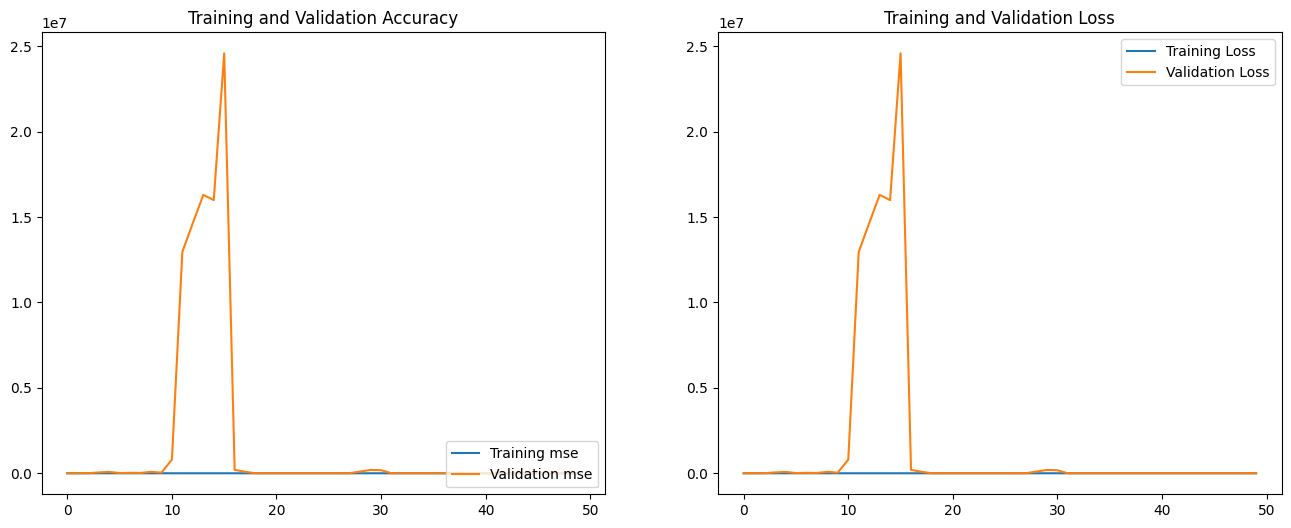

In [15]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['mse'], label='Training mse')
plt.plot(history.history['val_mse'],  label='Validation mse')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

- Makes predictions on the test set.

- Computes and prints:

    - R² (coefficient of determination) – negative values indicate the model performs worse than a simple mean predictor.

    - MSE from model.evaluate() (returns a list: [loss, mse]).

    - MSE computed manually.

    - RMSE computed from the manual MSE.
    The extremely negative R² (≈ -3.6) and large RMSE (≈20.26) confirm the model has failed to learn anything useful.

In [16]:
y_pred_test = model.predict(np.array(X_test.values))
R2 = r2_score(y_test, y_pred_test)
acc=model.evaluate(np.array(X_test.values),y_test)
mse_test_lr = mean_squared_error(y_test, y_pred_test)
rmse_test_lr = mse_test_lr**0.5



print("R2 =",R2 )
print('-'*60)
print("MSE =",acc)
print("-"*60)
print("MSE for test:", mse_test_lr)
print("-"*60)
print("RMSE for test:", rmse_test_lr)

285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 338.3739 - mse: 338.3739
R2 = -3.598920319105824
------------------------------------------------------------
MSE = [410.6622314453125, 410.6622314453125]
------------------------------------------------------------
MSE for test: 410.6622361752625
------------------------------------------------------------
RMSE for test: 20.264802890116215


2. LSTM

Sub‑header for the second deep learning model: a Long Short-Term Memory (LSTM) network. (Note: LSTM is typically used for sequential data; here it is applied to tabular data by reshaping each sample into a sequence of length 1.)

In [17]:
tf.random.set_seed(42)

# Convert to float
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Resahpe Because Data is not sequential
X_train_reshaped = np.reshape(X_train.values, (X_train.shape[0], 1, X_train.shape[1]))
X_test_reshaped  = np.reshape(X_test.values,  (X_test.shape[0], 1, X_test.shape[1]))

model2 = Sequential()
model2.add(LSTM(128, return_sequences=True, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
model2.add(Dropout(0.3))
model2.add(BatchNormalization())
model2.add(LSTM(64, return_sequences=False))
model2.add(Dropout(0.3))
model2.add(BatchNormalization())
model2.add(Dense(32, activation='relu'))
model2.add(Dropout(0.3))
model2.add(Dense(1, activation='linear'))
model2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mse']
)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


- Converts data to float and reshapes it to 3D (samples, timesteps, features). Here, timesteps = 1 because each sample is treated as a single time step.

- Builds an LSTM model:

    - First LSTM layer with 128 units, return_sequences=True (outputs sequences to feed into the next LSTM layer).

    -Dropout (0.3) and BatchNormalisation.

    - Second LSTM layer with 64 units, return_sequences=False (outputs a single vector).

    - A Dense layer with 32 neurons (ReLU) and dropout, followed by a linear output layer.

- Compiles with Adam (lr=0.001) and MSE loss.

In [18]:
history2 = model2.fit(
    X_train_reshaped,
    y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=64
)

Epoch 1/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 408.2145 - mse: 408.2145 - val_loss: 88.7513 - val_mse: 88.7513
Epoch 2/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 114.0680 - mse: 114.0680 - val_loss: 81.5795 - val_mse: 81.5795
Epoch 3/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 102.3254 - mse: 102.3254 - val_loss: 77.1901 - val_mse: 77.1901
Epoch 4/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 95.4903 - mse: 95.4903 - val_loss: 61.4676 - val_mse: 61.4676
Epoch 5/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 86.9663 - mse: 86.9663 - val_loss: 67.5566 - val_mse: 67.5566
Epoch 6/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 80.2519 - mse: 80.2519 - val_loss: 78.2477 - val_mse: 78.2477
Epoch 7/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 77.2781 - mse: 77.2781 - val_loss: 53.6618 - val_mse: 53.6618
Epoch 8/50
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 75.6094 - mse: 75.6094 - val_loss: 50.1681 - val_mse: 50.1681
Epoch 9/50


Trains the LSTM model for 50 epochs with batch size 64, using 20% of the training data for validation. The output shows that the validation loss decreases steadily and remains stable, indicating the model is learning well.

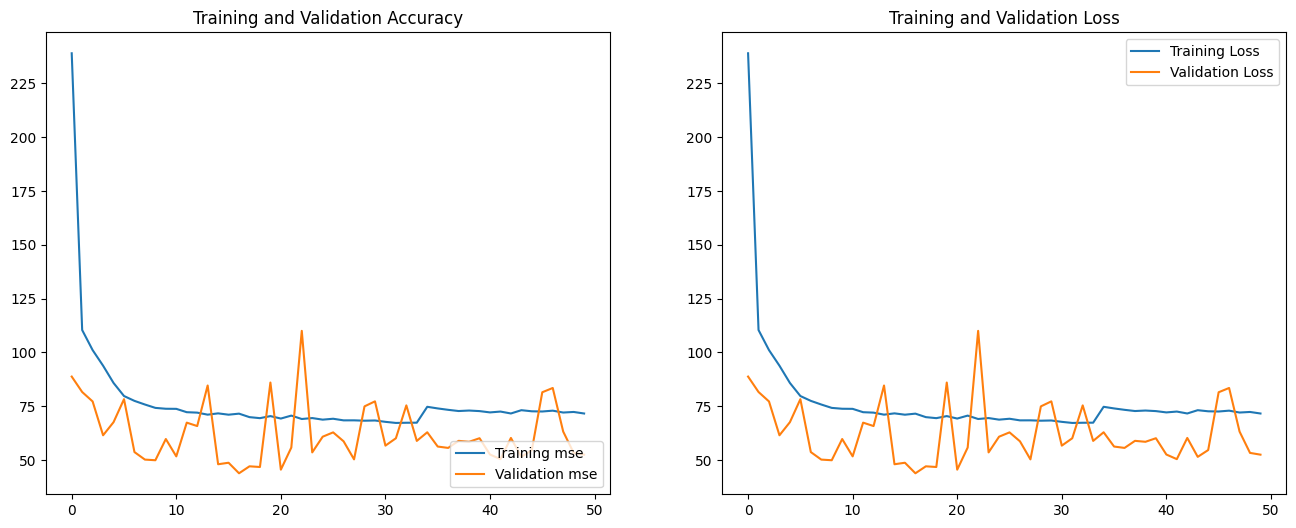

In [19]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(history2.history['mse'], label='Training mse')
plt.plot(history2.history['val_mse'],  label='Validation mse')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Plots the training/validation MSE and loss for the LSTM model. The curves show smooth convergence with no signs of divergence, confirming stable training.

In [20]:
X_test_reshaped = np.reshape(X_test.values, (X_test.shape[0], 1, X_test.shape[1]))
y_pred_test = model2.predict(X_test_reshaped)

R2 = r2_score(y_test, y_pred_test)
loss, mse = model2.evaluate(X_test_reshaped, y_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)

print("R2 =", R2)
print('-'*60)
print("Loss =", loss)
print('-'*60)
print("MSE (from model.evaluate) =", mse)
print("-"*60)
print("MSE (manual) =", mse_test)
print("-"*60)
print("RMSE =", rmse_test)

285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 55.0457 - mse: 55.0457
R2 = 0.3853655181071012
------------------------------------------------------------
Loss = 54.88398742675781
------------------------------------------------------------
MSE (from model.evaluate) = 54.88398742675781
------------------------------------------------------------
MSE (manual) = 54.88400608202702
------------------------------------------------------------
RMSE = 7.408374051168517


3. Residual NN

- Reshapes the test data to the 3D format expected by the LSTM.

- Makes predictions and evaluates the model.

- Prints metrics:

    - R² = 0.385 – positive and reasonable, indicating the model captures some variance.

    - Loss/MSE around 54.88.

- RMSE ≈ 7.41.
    The LSTM performs much better than the simple ANN.

In [21]:
tf.random.set_seed(42)


input_layer = Input(shape=(X_train.shape[1],))

# First block
x = Dense(256, activation='relu')(input_layer)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Residual Block 1
res = Dense(256, activation='relu')(x)
res = BatchNormalization()(res)
res = Dense(256)(res)
x = Add()([x, res])
x = tf.keras.activations.relu(x)

# Residual Block 2
res = Dense(128, activation='relu')(x)
res = BatchNormalization()(res)
res = Dense(128)(res)

# Match dimensions before addition
x = Dense(128)(x)
x = Add()([x, res])
x = tf.keras.activations.relu(x)

x = Dropout(0.3)(x)

output = Dense(1, activation='linear')(x)

model3 = Model(inputs=input_layer, outputs=output)

model3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mse']
)

Sub‑header for the third deep learning model: a Residual Neural Network (ResNet) built using the Keras Functional API.

In [22]:
early_stop = EarlyStopping(patience=15, restore_best_weights=True)
history3 = model3.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/200
456/456 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 149.3761 - mse: 149.3761 - val_loss: 111.7103 - val_mse: 111.7103
Epoch 2/200
456/456 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 56.3969 - mse: 56.3969 - val_loss: 96.0829 - val_mse: 96.0829
Epoch 3/200
456/456 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 51.2381 - mse: 51.2381 - val_loss: 107.2227 - val_mse: 107.2227
Epoch 4/200
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 49.0451 - mse: 49.0451 - val_loss: 102.3976 - val_mse: 102.3976
Epoch 5/200
456/456 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 50.1694 - mse: 50.1694 - val_loss: 90.2653 - val_mse: 90.2653
Epoch 6/200
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 46.1568 - mse: 46.1568 - val_loss: 164.6350 - val_mse: 164.6350
Epoch 7/200
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 44.1571 - mse: 44.1571 - val_loss: 73.5608 - val_mse: 73.5608
Epoch 8/200
456/456 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 42.0680 - mse: 42.0680 - val_loss: 104.1756 - val_mse: 104.1

Builds a residual network using the Functional API:

First block: A Dense layer (256) + BatchNorm + Dropout.

Residual Block 1:

A two‑layer sub‑network (256 → 256) with BatchNorm in between.

The output of this block is added to the original x (skip connection), then passed through a ReLU activation.

Residual Block 2:

A two‑layer sub‑network (128 → 128) with BatchNorm.

Before adding, x is projected to 128 dimensions via a Dense layer.

The addition is followed by ReLU.

Final Dropout and a linear output layer.

The model is compiled with Adam (lr=0.001) and MSE loss.

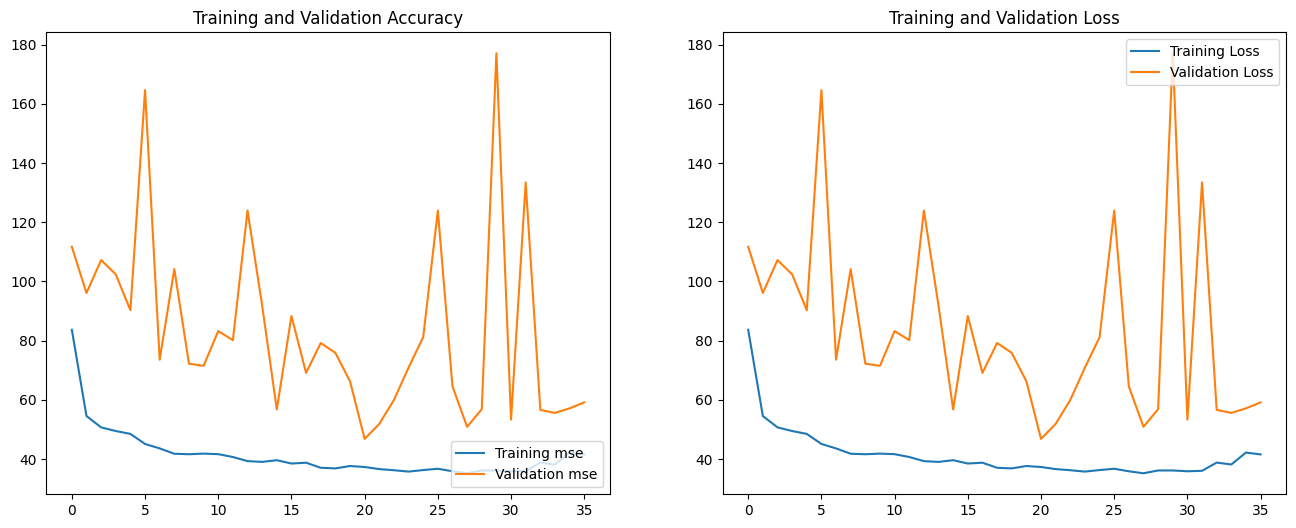

In [23]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(history3.history['mse'], label='Training mse')
plt.plot(history3.history['val_mse'],  label='Validation mse')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history3.history['loss'], label='Training Loss')
plt.plot(history3.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Important: This cell uses model (the simple ANN from earlier), not the residual network model3. This is likely a copy‑paste error.

It computes predictions and metrics for the simple ANN, which are the same poor results seen before (R² ≈ -3.6, RMSE ≈ 20.26).
To evaluate the residual network, one should use model3.predict(X_test) and model3.evaluate(...).1

In [24]:
y_pred_test = model.predict(X_test)
y_pred_test = y_pred_test.flatten()



R2 = r2_score(y_test, y_pred_test)
loss, mse = model.evaluate(X_test, y_test, verbose=0)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)


print("R2 =", R2)
print('-'*60)
print("Loss =", loss)
print('-'*60)
print("MSE (from model.evaluate) =", mse)
print("-"*60)
print("MSE (manual) =", mse_test)
print("-"*60)
print("RMSE =", rmse_test)

285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
R2 = -3.598920319105824
------------------------------------------------------------
Loss = 410.6622314453125
------------------------------------------------------------
MSE (from model.evaluate) = 410.6622314453125
------------------------------------------------------------
MSE (manual) = 410.6622361752625
------------------------------------------------------------
RMSE = 20.264802890116215
